# 4x3 Grid World: Monte Carlo Methods

## Installation and Setup

You need:
* Gymnasium (see [Installation Instructions](../Intro/Setup_Gymnasium.ipynb))
* Patched `gym-classics-1.0.0+internal.rev1` or later (see [Installation instructions](../common/Setup_patched_gym_classics.ipynb))

In [5]:
import numpy as np
np.set_printoptions(precision=2)

In [6]:
import gymnasium as gym
import gym_classics
gym_classics.register('gymnasium')

from gym_classics.utils import print_gridworld
from gym_classics.animation import gridworld_animate
                                    
from gym_classics.algorithms import random_policy

## Define the $4 \times 3$ Grid World

The used example is the simple $4 \times 3$ grid world described in AIMA Chapter 17.

![4x3 grid world description](https://raw.githubusercontent.com/mhahsler/Introduction_to_Reinforcement_Learning/refs/heads/main/DP/figures/AIMA_Figure_17_1.png)

AIMA Figure 17.1: (a) A simple, stochastic 
 environment that presents the agent with a sequential decision problem. (b) Illustration of the transition model of the environment: the “intended” outcome occurs with probability 0.8, but with probability 0.2 the agent moves at right angles to the intended direction. A collision with a wall results in no movement. Transitions into the two terminal states have reward +1 and -1, respectively, and all other transitions have a reward of -0.04.


`gym_classic` defines an abstract gridworld class. Here we extend the `NoisyGridWorld` which implements the non-determnistic 80/10/10 navigation actions for 
the example.

In [7]:
from gym_classics.envs.abstract.noisy_gridworld import NoisyGridworld

class OriginalClassicGridworld(NoisyGridworld):
    layout = """
|   G|
| X G|
|S   |
"""

    def __init__(self):
        super().__init__(OriginalClassicGridworld.layout)

    def _reward(self, state, action, next_state):
        return {(3, 1): -1.0, (3, 2): 1.0}.get(state, -0.04)

    def _done(self, state, action, next_state):
        return state in self._goals  

gym.register('OriginalClassicGridworld-v0', entry_point=OriginalClassicGridworld)

We can use `make()` to create registered environments. Gymnasium uses wrappers, so we have unwrap the environment first to get the extended model API.

In [8]:
gym_env = gym.make('OriginalClassicGridworld-v0')
env = gym_env.unwrapped

## Monte Carlo Prediction

Estimate the value function for a policy using sample trajectories. This is also called policy evaluation. 

![Monte Carlo Prediciton](https://raw.githubusercontent.com/mhahsler/Introduction_to_Reinforcement_Learning/refs/heads/main/figures/RL_Alg_MC_Prediction.png)

In [9]:
manual_pol = [env.encode_action("up")] * len(env.states())
manual_pol[2] = env.encode_action("right")
manual_pol[4] = env.encode_action("right")
manual_pol[7] = env.encode_action("right")

manual_pol

[0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0]

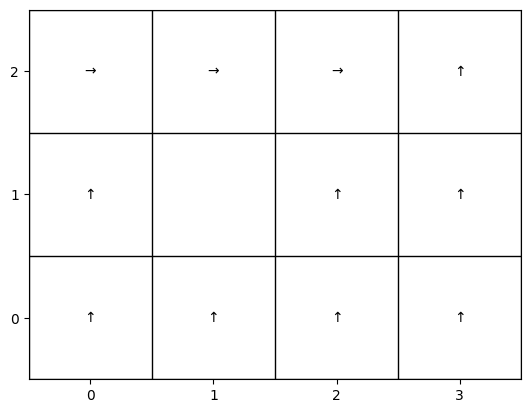

In [10]:
env.image(policy = manual_pol)

In [18]:
def sample_episode(env, policy, start_state = None, start_action = None, max_len = 1000):
    """sample complete episodes. The starting (s,a) can be specified."""
    episode = []
    
    s, r = env.reset()
    
    if not start_state is None:
        s = start_state
        env.state = env.decode(s)
    
    step = 0
    done = False
    while not done and step < max_len:
        a = policy[s]
        
        if step == 0 and not start_action is None:
            a = start_action
        
        sp, reward, done, _, _ = env.step(a)
        episode.append((s,a,reward,sp))
        
        s = sp
        step += 1
        
    return(episode)
    
sample_episode(env, manual_pol)


[(0, 0, -0.04, 1),
 (1, 0, -0.04, 1),
 (1, 0, -0.04, 2),
 (2, 1, -0.04, 4),
 (4, 1, -0.04, 4),
 (4, 1, -0.04, 7),
 (7, 1, -0.04, 10),
 (10, 0, 1.0, 10)]

In [214]:
def MC_prediction(env, policy, discount, n = 100):
    #V = np.zeros(len(env.states()))
    Returns = [[] for _ in env.states()]
    
    for i in range(n):
        episode = sample_episode(env, policy)
        G = 0
        
        # process episode in reverse order
        for t in range(len(episode)-1, -1, -1):
            s,a,r,sp = episode[t]
            G = discount * G + r

            # use first visit only
            if not s in [step[0] for step in episode][0:t]:
                Returns[s].append(G)
                  
    # calculate all state value
    V = [np.mean(G) for G in Returns]
    return V  

In [213]:
V_MC = MC_prediction(env, manual_pol, 1)
V_MC

[np.float64(0.6941592920353981),
 np.float64(0.7663636363636361),
 np.float64(0.7966101694915251),
 np.float64(0.4753488372093021),
 np.float64(0.8596551724137931),
 np.float64(0.46399999999999986),
 np.float64(0.718095238095238),
 np.float64(0.9266141732283463),
 np.float64(-1.1400000000000001),
 np.float64(-1.0),
 np.float64(1.0)]

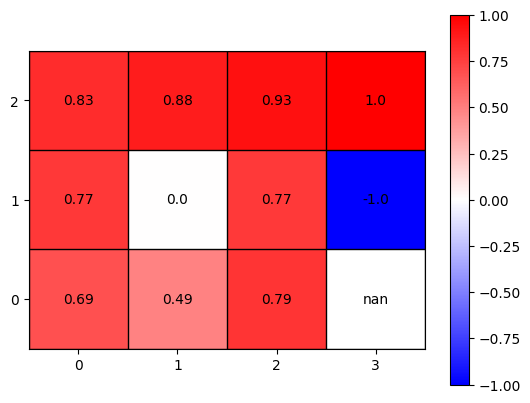

In [90]:
env.image(V_MC, labels = True)

## Monte Carlo Control

Find the optimal policy using MC.

Many $(s,a)$-pairs will never be visited when following $\pi$. We need to keep exploring! 

Options:
* Exploring starts: choose the starting $(s,a)$ for each episode randomly.
* Only consider soft policies like $\epsilon$-greedy. Soft policies have non-zero probabilities for all actions.


### MC Control with Exploring Starts

Start episodes randomly from all possible $(a,s)$ pairs.

![MC Control with ES](https://raw.githubusercontent.com/mhahsler/Introduction_to_Reinforcement_Learning/refs/heads/main/figures/RL_Alg_MC_Control_ES.png)

In [ ]:
from collections import defaultdict

# np.argmax does not break ties randomly
def random_argmax(x):
    return np.random.choice(np.where(x == np.max(x))[0])

def MC_control_ES(env, discount, n = 100, max_episode_len = 100):
    policy = random_policy(env)
    Q = np.zeros((len(env.states()), len(env.actions())))
    Returns = defaultdict(list) # a list for each (s,a)
    
    for i in range(n):
        # Sample starting (s,a)
        s = np.random.choice(env.states())
        a = np.random.choice(env.actions())
        
        episode = sample_episode(env, policy, start_state = 2, start_action = a, max_len=max_episode_len)
        G = 0
           
        # process episode in reverse order
        for t in range(len(episode)-1, -1, -1):
            s,a,r,sp = episode[t]
            G = discount * G + r
            print(r)
            # use first visit only
            #if not s in [step[0] for step in episode][0:t]:
            if True:
                Returns[(s,a)].append(G)
            
                # update policy
                Q[s,a] = np.mean(Returns[(s,a)])
                policy[s] = random_argmax(Q[s,:])
          
    return policy, Q, Returns

In [228]:
pol, Q, Returns = MC_control_ES(env, discount=1, n = 10)


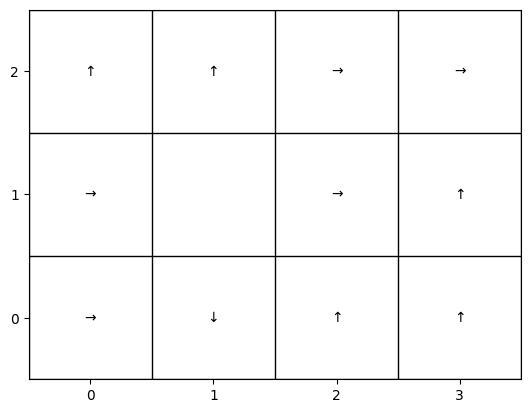

In [229]:

env.image(policy = pol)


In [230]:
display(Q)
#display(Returns)
Returns[(0,0)], Returns[(0,1)], Returns[(0,2)], Returns[(0,3)]

array([[-1.7 ,  0.  , -3.62,  0.  ],
       [-2.12,  0.  , -3.96, -2.27],
       [-1.54, -1.94, -3.39, -2.45],
       [-1.18, -3.17,  0.  ,  0.  ],
       [-0.93, -2.68, -1.51, -2.68],
       [-1.08, -1.27, -1.58, -3.15],
       [-3.  , -1.04, -1.72, -3.12],
       [-0.62, -0.06, -3.32, -2.51],
       [ 0.  , -1.24, -1.5 ,  0.  ],
       [ 0.  , -1.  , -1.  , -1.  ],
       [ 0.  ,  1.  ,  0.  ,  0.  ]])

([-1.2800000000000002, -2.120000000000001],
 [],
 [-3.320000000000002,
  -3.360000000000002,
  -3.400000000000002,
  -3.440000000000002,
  -3.480000000000002,
  -3.5200000000000022,
  -3.5600000000000023,
  -3.6000000000000023,
  -3.6400000000000023,
  -3.6800000000000024,
  -3.7200000000000024,
  -3.7600000000000025,
  -3.8000000000000025,
  -3.8400000000000025,
  -3.8800000000000026,
  -3.9200000000000026],
 [])

numpy.float64


&copy; 2025 [Michael Hahsler](http://michael.hahsler.net). 
This work is openly licensed under [Creative Commons Attribution-ShareAlike 4.0 International (CC BY-SA 4.0) License](https://creativecommons.org/licenses/by-sa/4.0/)

![CC BY-SA 4.0](https://licensebuttons.net/l/by-sa/3.0/88x31.png)